1. Caricamento e pulizia dati

- Separa le colonne Naive Bayes
- Prepara il dataset pulito

2. Clustering per blocchi tematici
Per ogni blocco (Demografia, Comportamento, Utilizzo, Transazioni):

- Preprocessing automatico: distingue feature numeriche/categoriche
- KMeans con k ottimale: usa Elbow + Silhouette per trovare il numero ideale di cluster
- DBSCAN: grid search su eps per trovare configurazione ottimale
- Valutazione: silhouette, Davies-Bouldin, Calinski-Harabasz
- Analisi churn: quanto ogni cluster discrimina l'abbandono
- Caratterizzazione: identifica le caratteristiche distintive di ogni cluster (medie, modalità, differenze % rispetto al dataset)
- Visualizzazione 2D: PCA per vedere i cluster e il churn

3. Clustering con TUTTE le feature

- Stesso processo ma usando tutte le variabili disponibili
- Visualizzazione sia con PCA che t-SNE

4. Confronto finale

- Tabella comparativa di tutti i modelli
- Identificazione delle configurazioni migliori

📊 Caratteristiche chiave

- Caratterizzazione automatica: per ogni cluster mostra le medie delle variabili numeriche con % di differenza rispetto alla media generale
- Analisi categoriche: mostra la modalità dominante in ogni cluster
- Metriche multiple: non solo silhouette, ma anche Davies-Bouldin (più basso = meglio) e Calinski-Harabasz (più alto = meglio)
- Churn rate per cluster: vedi quali cluster hanno più abbandoni
- Visualizzazioni intuitive: plot affiancati cluster vs churn

Il codice salva automaticamente tutte le etichette dei cluster nel DataFrame finale, permettendoti di fare analisi successive!

In [2]:
# =======================
# CLUSTER ANALYSIS - BANK CHURNERS
# =======================

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# =======================
# STEP 1: Caricamento dati
# =======================
df_clean = pd.read_csv("./Dati_puliti/BankChurners_senza_predizione_NB.csv")
df_clean

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,Existing Customer,50,M,2,Graduate,Single,$40K - $60K,Blue,40,3,2,3,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462
10123,Attrited Customer,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,4,2,3,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511
10124,Attrited Customer,44,F,1,High School,Married,Less than $40K,Blue,36,5,3,4,5409.0,0,5409.0,0.819,10291,60,0.818,0.000
10125,Attrited Customer,30,M,2,Graduate,Unknown,$40K - $60K,Blue,36,4,3,3,5281.0,0,5281.0,0.535,8395,62,0.722,0.000


In [3]:

print("=" * 60)
print("DATASET CARICATO")
print("=" * 60)
print(f"Shape dataset pulito: {df_clean.shape}")

print(f"\nColonne: {list(df_clean.columns)}")

# =======================
# STEP 2: Definizione blocchi di feature
# =======================
blocks = {
    "Demografia": [
        "Customer_Age", "Gender", "Dependent_count",
        "Education_Level", "Marital_Status", "Income_Category"
    ],
    "Comportamento": [
        "Months_on_book", "Months_Inactive_12_mon",
        "Contacts_Count_12_mon", "Total_Relationship_Count"
    ],
    "Utilizzo": [
        "Credit_Limit", "Total_Revolving_Bal",
        "Avg_Open_To_Buy", "Avg_Utilization_Ratio"
    ],
    "Transazioni": [
        "Total_Trans_Amt", "Total_Trans_Ct",
        "Total_Amt_Chng_Q4_Q1", "Total_Ct_Chng_Q4_Q1"
    ]
}

DATASET CARICATO
Shape dataset pulito: (10127, 20)

Colonne: ['Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']


In [4]:
# =======================
# STEP 3: Funzioni di utilità
# =======================
def build_preprocessor(features, df):
    """Crea un ColumnTransformer per numeriche (scaling) e categoriche (one-hot)."""
    numeric = df[features].select_dtypes(include=["int64", "float64"]).columns.tolist()
    categorical = df[features].select_dtypes(exclude=["int64", "float64"]).columns.tolist()
    
    transformers = []
    if numeric:
        transformers.append(("num", StandardScaler(), numeric))
    if categorical:
        transformers.append(("cat", OneHotEncoder(drop="first", sparse_output=False), categorical))
    
    preprocessor = ColumnTransformer(transformers)
    return preprocessor, numeric, categorical


def find_optimal_k(X, max_k=10):
    """Trova il k ottimale usando Elbow Method e Silhouette Score."""
    inertias = []
    silhouettes = []
    K_range = range(2, max_k + 1)
    
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        inertias.append(kmeans.inertia_)
        silhouettes.append(silhouette_score(X, labels))
    
    # Trova il k ottimale (max silhouette)
    optimal_k = K_range[np.argmax(silhouettes)]
    
    return K_range, inertias, silhouettes, optimal_k


def evaluate_clusters(X, labels, target, block_name):
    """Valuta la qualità dei cluster."""
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    results = {
        "Block": block_name,
        "N_Clusters": n_clusters,
        "Silhouette": silhouette_score(X, labels) if n_clusters > 1 else -1,
        "Davies_Bouldin": davies_bouldin_score(X, labels) if n_clusters > 1 else -1,
        "Calinski_Harabasz": calinski_harabasz_score(X, labels) if n_clusters > 1 else -1
    }
    
    # Analisi churn per cluster
    df_temp = pd.DataFrame({"Cluster": labels, "Attrition": target})
    cluster_stats = df_temp.groupby("Cluster").agg({
        "Attrition": ["count", lambda x: (x == "Attrited Customer").sum(), 
                      lambda x: (x == "Attrited Customer").mean()]
    })
    cluster_stats.columns = ["Size", "Churned", "Churn_Rate"]
    
    return results, cluster_stats


def plot_cluster_analysis(K_range, inertias, silhouettes, optimal_k, block_name):
    """Plotta Elbow e Silhouette per trovare k ottimale."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Elbow plot
    axes[0].plot(K_range, inertias, 'bo-')
    axes[0].set_xlabel('Numero di Cluster (k)')
    axes[0].set_ylabel('Inertia')
    axes[0].set_title(f'Elbow Method - {block_name}')
    axes[0].grid(True, alpha=0.3)
    
    # Silhouette plot
    axes[1].plot(K_range, silhouettes, 'ro-')
    axes[1].axvline(optimal_k, color='g', linestyle='--', label=f'Ottimale k={optimal_k}')
    axes[1].set_xlabel('Numero di Cluster (k)')
    axes[1].set_ylabel('Silhouette Score')
    axes[1].set_title(f'Silhouette Analysis - {block_name}')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def characterize_clusters(df, features, labels, block_name, numeric_cols, categorical_cols):
    """Caratterizza i cluster trovando le caratteristiche distintive."""
    df_analysis = df[features].copy()
    df_analysis['Cluster'] = labels
    
    print(f"\n{'=' * 60}")
    print(f"CARATTERIZZAZIONE CLUSTER - {block_name}")
    print(f"{'=' * 60}\n")
    
    # Analisi per ogni cluster
    for cluster_id in sorted(df_analysis['Cluster'].unique()):
        if cluster_id == -1:  # Noise in DBSCAN
            continue
            
        cluster_data = df_analysis[df_analysis['Cluster'] == cluster_id]
        print(f"\n--- CLUSTER {cluster_id} (n={len(cluster_data)}) ---")
        
        # Statistiche numeriche
        if numeric_cols:
            print("\nCaratteristiche numeriche medie:")
            for col in numeric_cols:
                cluster_mean = cluster_data[col].mean()
                overall_mean = df_analysis[col].mean()
                diff_pct = ((cluster_mean - overall_mean) / overall_mean) * 100
                print(f"  {col}: {cluster_mean:.2f} (media generale: {overall_mean:.2f}, diff: {diff_pct:+.1f}%)")
        
        # Statistiche categoriche
        if categorical_cols:
            print("\nDistribuzione variabili categoriche:")
            for col in categorical_cols:
                mode_val = cluster_data[col].mode()[0]
                mode_pct = (cluster_data[col] == mode_val).sum() / len(cluster_data) * 100
                print(f"  {col}: {mode_val} ({mode_pct:.1f}%)")


def visualize_clusters_2d(X, labels, target, block_name, method='PCA'):
    """Visualizza i cluster in 2D usando PCA o t-SNE."""
    if method == 'PCA':
        reducer = PCA(n_components=2, random_state=42)
    else:
        reducer = TSNE(n_components=2, random_state=42, perplexity=30)
    
    X_2d = reducer.fit_transform(X)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Cluster
    scatter1 = axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='viridis', 
                               alpha=0.6, s=30, edgecolors='k', linewidth=0.3)
    axes[0].set_title(f'{method} - Cluster ({block_name})')
    axes[0].set_xlabel(f'{method}1')
    axes[0].set_ylabel(f'{method}2')
    plt.colorbar(scatter1, ax=axes[0], label='Cluster')
    
    # Plot 2: Churn
    churn_binary = (target == "Attrited Customer").astype(int)
    scatter2 = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=churn_binary, cmap='RdYlGn_r', 
                               alpha=0.6, s=30, edgecolors='k', linewidth=0.3)
    axes[1].set_title(f'{method} - Churn ({block_name})')
    axes[1].set_xlabel(f'{method}1')
    axes[1].set_ylabel(f'{method}2')
    plt.colorbar(scatter2, ax=axes[1], label='Churn', ticks=[0, 1])
    
    plt.tight_layout()
    plt.show()
    
    if method == 'PCA':
        print(f"\nVarianza spiegata: {reducer.explained_variance_ratio_.sum():.2%}")




############################################################
# ANALISI BLOCCO: Demografia
############################################################

Features trasformate: (10127, 17)
  - Numeriche: ['Customer_Age', 'Dependent_count']
  - Categoriche: ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category']

--- KMeans Clustering ---


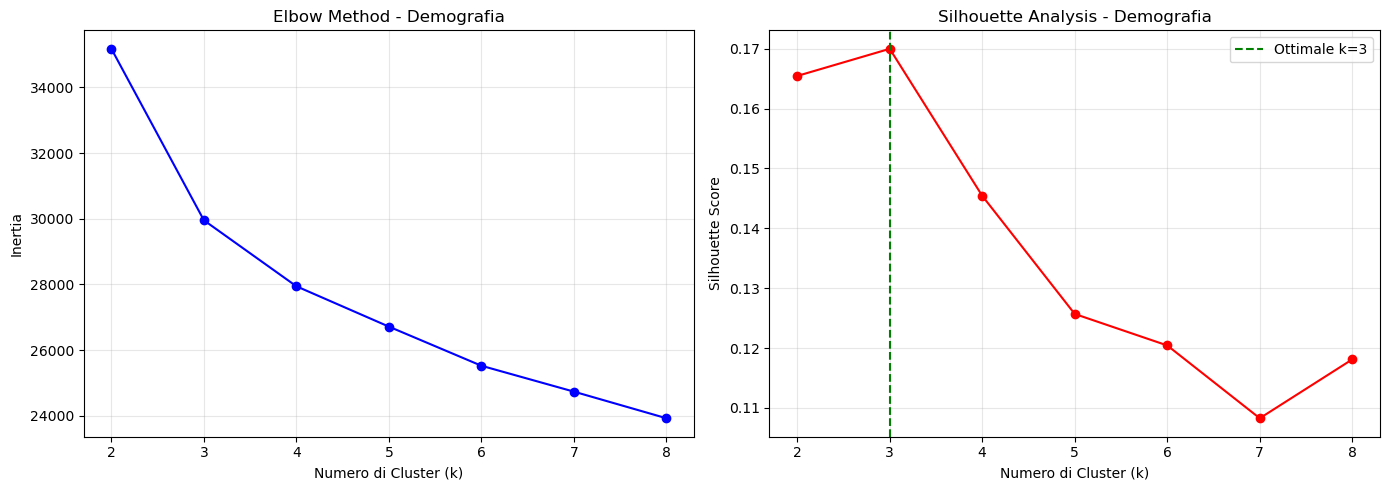


Metriche KMeans (k=3):
  Silhouette: 0.170
  Davies-Bouldin: 1.797
  Calinski-Harabasz: 2194.0

Statistiche Cluster:
         Size  Churned  Churn_Rate
Cluster                           
0        4277      731    0.170914
1        3261      520    0.159460
2        2589      376    0.145230

CARATTERIZZAZIONE CLUSTER - Demografia


--- CLUSTER 0 (n=4277) ---

Caratteristiche numeriche medie:
  Customer_Age: 45.73 (media generale: 46.33, diff: -1.3%)
  Dependent_count: 3.57 (media generale: 2.35, diff: +52.0%)

Distribuzione variabili categoriche:
  Gender: F (52.7%)
  Education_Level: Graduate (31.1%)
  Marital_Status: Married (46.3%)
  Income_Category: Less than $40K (33.6%)

--- CLUSTER 1 (n=3261) ---

Caratteristiche numeriche medie:
  Customer_Age: 54.19 (media generale: 46.33, diff: +17.0%)
  Dependent_count: 1.35 (media generale: 2.35, diff: -42.5%)

Distribuzione variabili categoriche:
  Gender: F (53.6%)
  Education_Level: Graduate (30.2%)
  Marital_Status: Married (50.3%)
  I

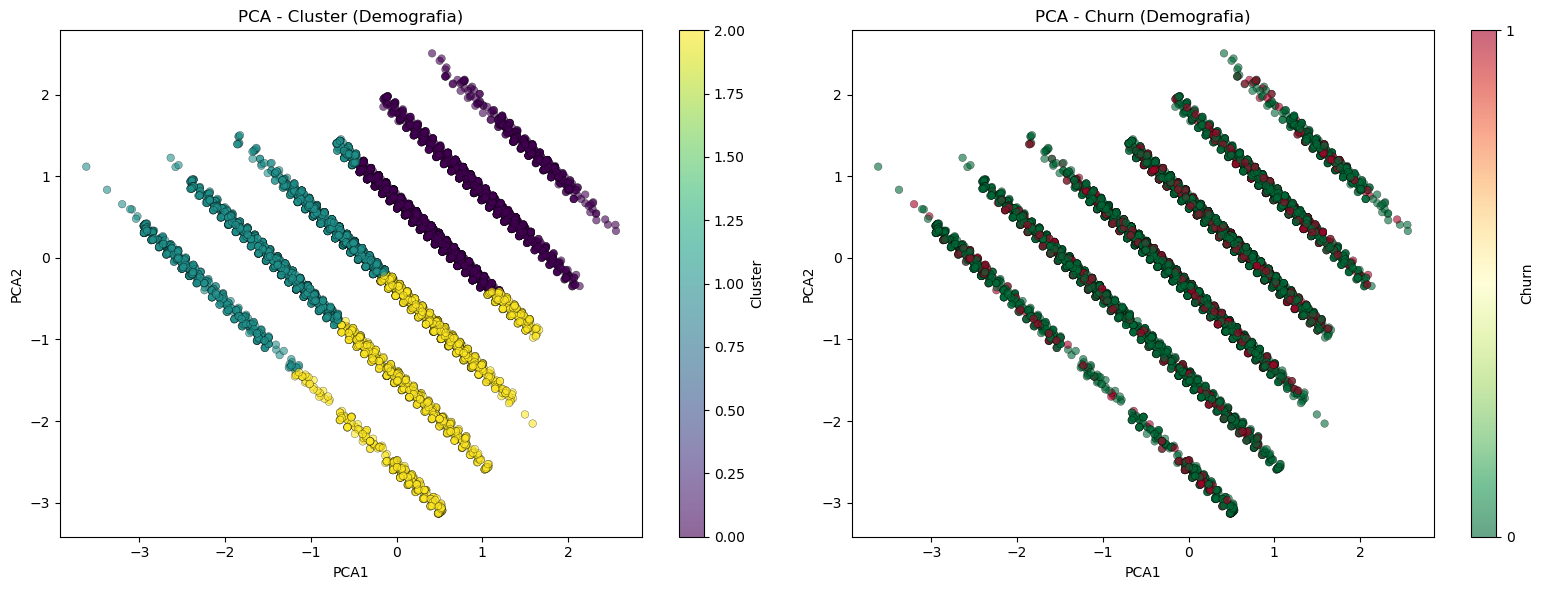


Varianza spiegata: 47.26%

--- DBSCAN Clustering ---
  eps=0.5: 444 cluster, silhouette=0.056
  eps=1.0: 7 cluster, silhouette=-0.130

Migliore configurazione DBSCAN (eps=0.5):
  Silhouette: 0.056

Statistiche Cluster:
         Size  Churned  Churn_Rate
Cluster                           
-1       2713      409    0.150756
 0         48        6    0.125000
 1         16        1    0.062500
 2         67       10    0.149254
 3          7        3    0.428571
...       ...      ...         ...
 439        5        0    0.000000
 440        5        1    0.200000
 441        5        2    0.400000
 442        5        4    0.800000
 443        5        2    0.400000

[445 rows x 3 columns]


############################################################
# ANALISI BLOCCO: Comportamento
############################################################

Features trasformate: (10127, 4)
  - Numeriche: ['Months_on_book', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Total_Relationship_Count'

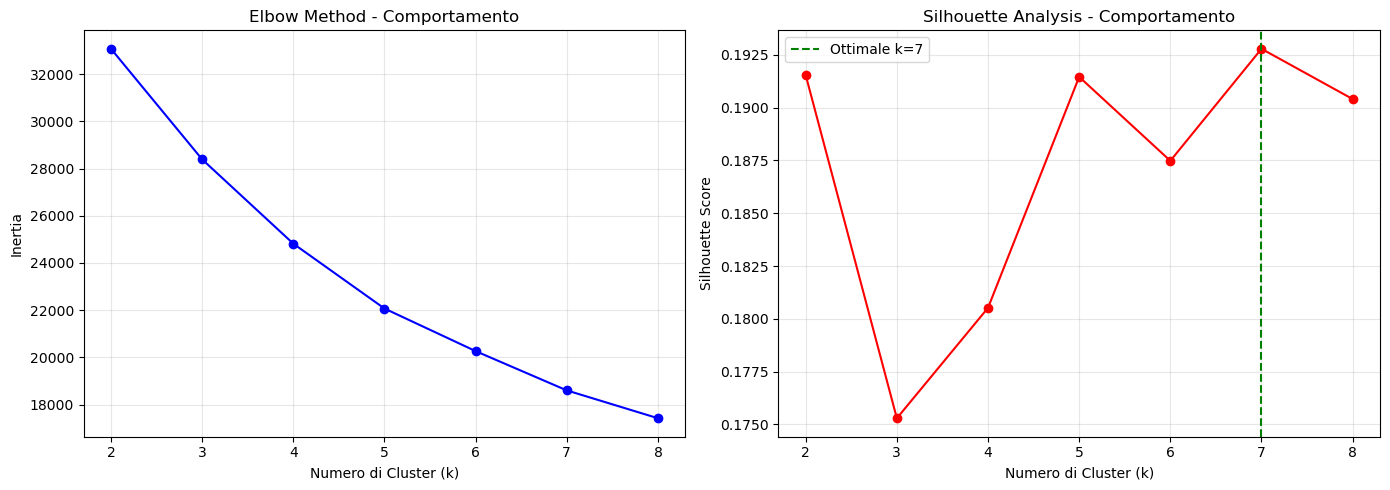


Metriche KMeans (k=7):
  Silhouette: 0.193
  Davies-Bouldin: 1.324
  Calinski-Harabasz: 1986.4

Statistiche Cluster:
         Size  Churned  Churn_Rate
Cluster                           
0        1185      159    0.134177
1        1887      244    0.129306
2        1507      484    0.321168
3         651      156    0.239631
4        1120      113    0.100893
5        1926      156    0.080997
6        1851      315    0.170178

CARATTERIZZAZIONE CLUSTER - Comportamento


--- CLUSTER 0 (n=1185) ---

Caratteristiche numeriche medie:
  Months_on_book: 22.44 (media generale: 35.93, diff: -37.5%)
  Months_Inactive_12_mon: 2.03 (media generale: 2.34, diff: -13.3%)
  Contacts_Count_12_mon: 2.67 (media generale: 2.46, diff: +8.7%)
  Total_Relationship_Count: 4.01 (media generale: 3.81, diff: +5.1%)

--- CLUSTER 1 (n=1887) ---

Caratteristiche numeriche medie:
  Months_on_book: 36.16 (media generale: 35.93, diff: +0.6%)
  Months_Inactive_12_mon: 2.21 (media generale: 2.34, diff: -5.6%)
  Cont

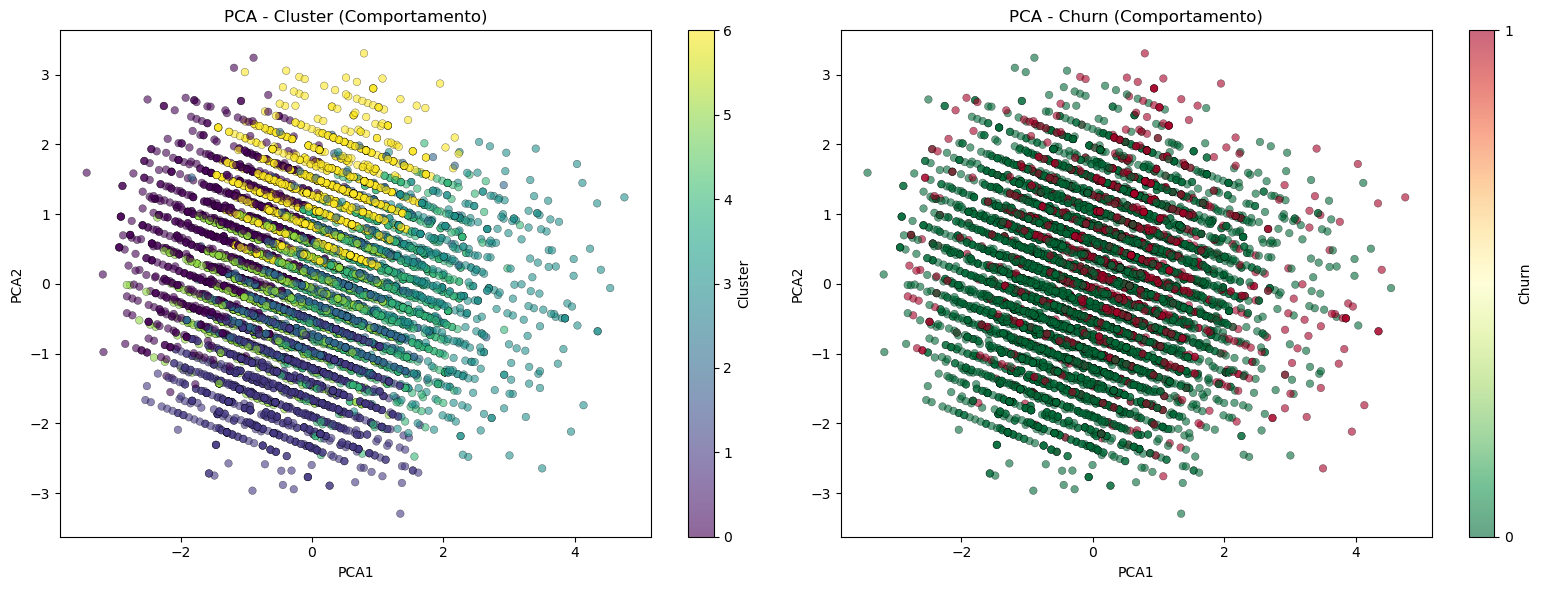


Varianza spiegata: 53.38%

--- DBSCAN Clustering ---
  eps=0.5: 136 cluster, silhouette=0.124

Migliore configurazione DBSCAN (eps=0.5):
  Silhouette: 0.124

Statistiche Cluster:
         Size  Churned  Churn_Rate
Cluster                           
-1        727      209    0.287483
 0        126        5    0.039683
 1        131        2    0.015267
 2          9        0    0.000000
 3         11        0    0.000000
...       ...      ...         ...
 131        5        4    0.800000
 132        8        1    0.125000
 133        5        0    0.000000
 134        6        3    0.500000
 135        5        5    1.000000

[137 rows x 3 columns]


############################################################
# ANALISI BLOCCO: Utilizzo
############################################################

Features trasformate: (10127, 4)
  - Numeriche: ['Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Avg_Utilization_Ratio']
  - Categoriche: []

--- KMeans Clustering ---


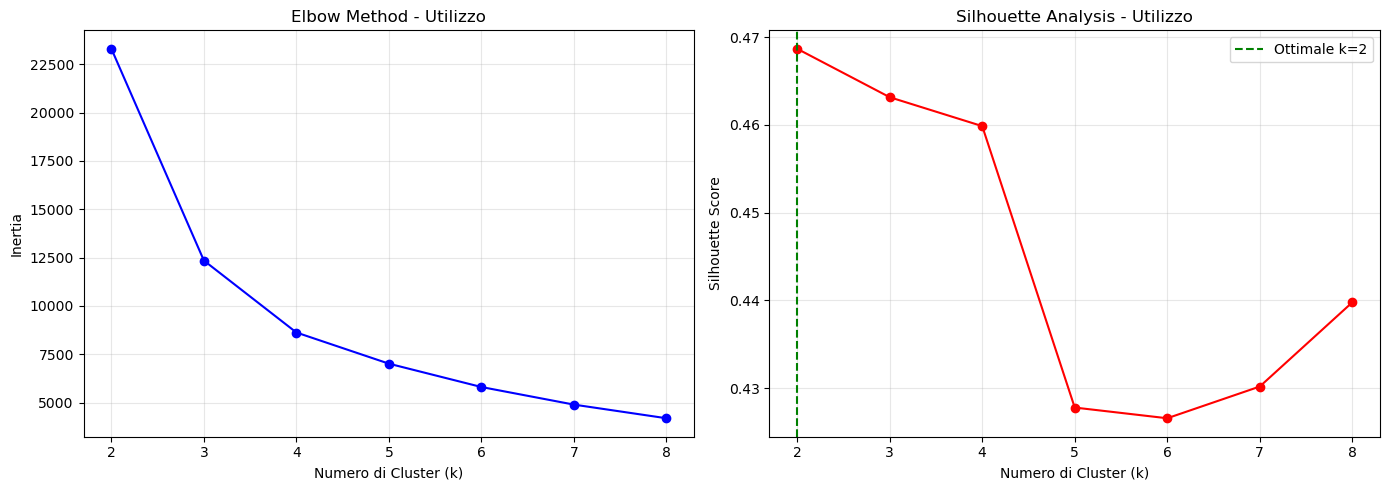


Metriche KMeans (k=2):
  Silhouette: 0.469
  Davies-Bouldin: 0.871
  Calinski-Harabasz: 7474.6

Statistiche Cluster:
         Size  Churned  Churn_Rate
Cluster                           
0        1994      296    0.148445
1        8133     1331    0.163654

CARATTERIZZAZIONE CLUSTER - Utilizzo


--- CLUSTER 0 (n=1994) ---

Caratteristiche numeriche medie:
  Credit_Limit: 24672.67 (media generale: 8631.95, diff: +185.8%)
  Total_Revolving_Bal: 1117.22 (media generale: 1162.81, diff: -3.9%)
  Avg_Open_To_Buy: 23555.45 (media generale: 7469.14, diff: +215.4%)
  Avg_Utilization_Ratio: 0.05 (media generale: 0.27, diff: -82.6%)

--- CLUSTER 1 (n=8133) ---

Caratteristiche numeriche medie:
  Credit_Limit: 4699.19 (media generale: 8631.95, diff: -45.6%)
  Total_Revolving_Bal: 1173.99 (media generale: 1162.81, diff: +1.0%)
  Avg_Open_To_Buy: 3525.19 (media generale: 7469.14, diff: -52.8%)
  Avg_Utilization_Ratio: 0.33 (media generale: 0.27, diff: +20.3%)


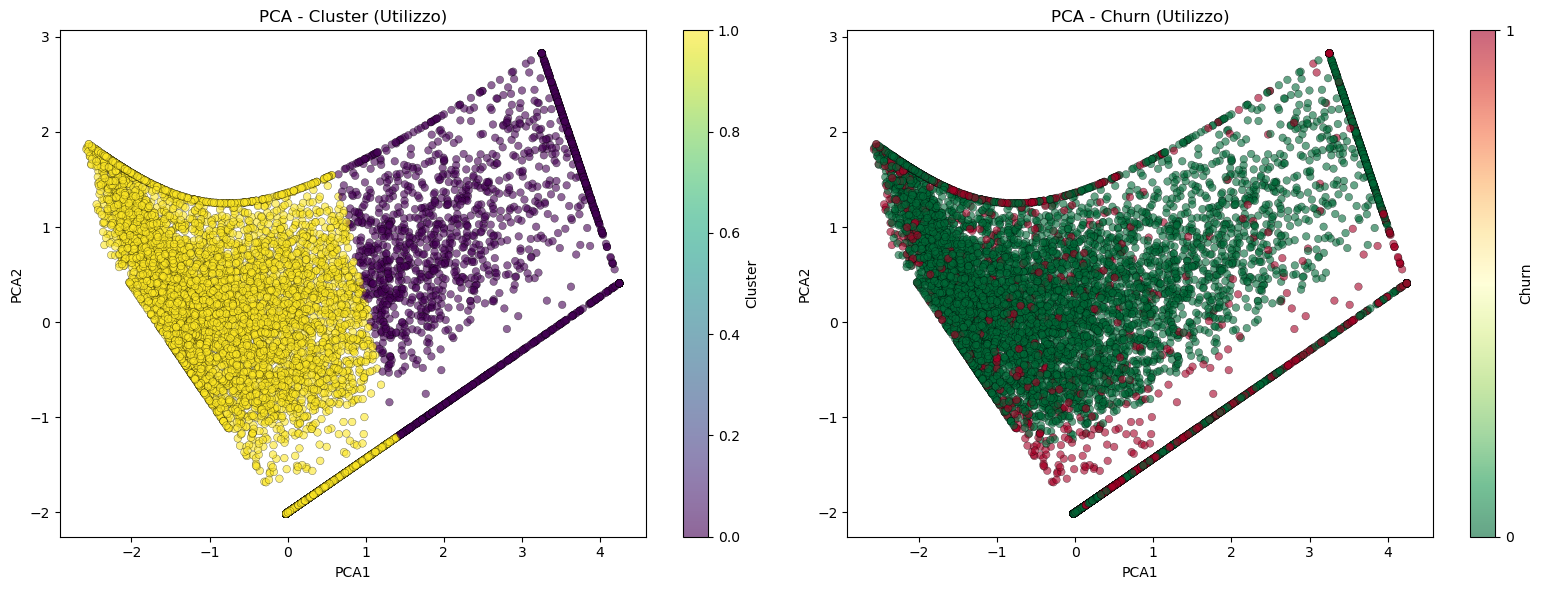


Varianza spiegata: 94.65%

--- DBSCAN Clustering ---
DBSCAN non ha trovato cluster significativi.


############################################################
# ANALISI BLOCCO: Transazioni
############################################################

Features trasformate: (10127, 4)
  - Numeriche: ['Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Amt_Chng_Q4_Q1', 'Total_Ct_Chng_Q4_Q1']
  - Categoriche: []

--- KMeans Clustering ---


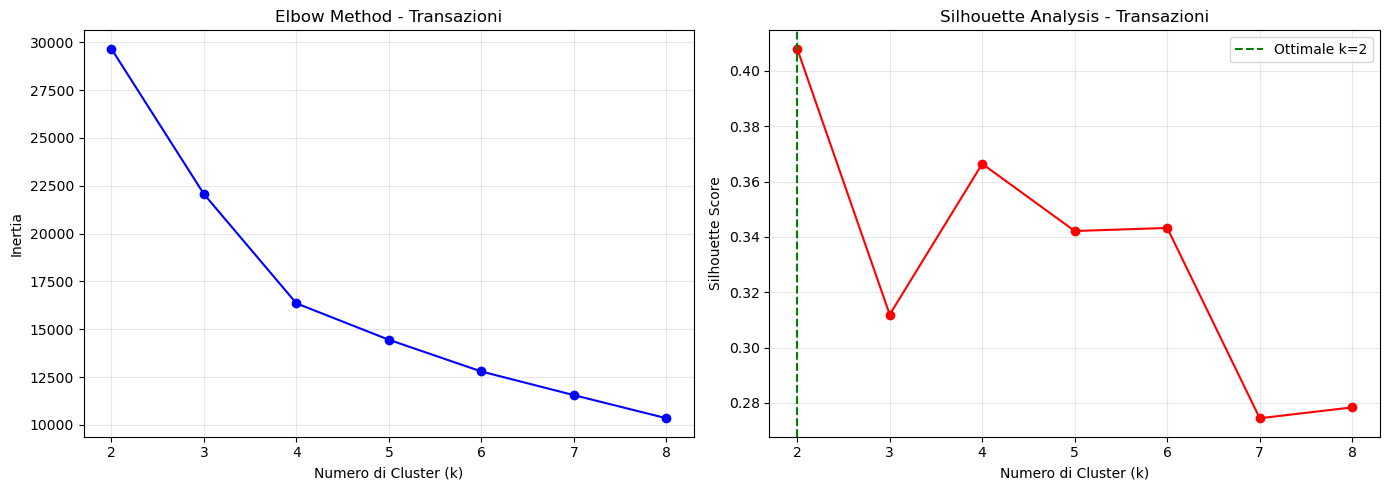


Metriche KMeans (k=2):
  Silhouette: 0.408
  Davies-Bouldin: 0.878
  Calinski-Harabasz: 3705.0

Statistiche Cluster:
         Size  Churned  Churn_Rate
Cluster                           
0        8916     1544    0.173172
1        1211       83    0.068538

CARATTERIZZAZIONE CLUSTER - Transazioni


--- CLUSTER 0 (n=8916) ---

Caratteristiche numeriche medie:
  Total_Trans_Amt: 3342.13 (media generale: 4404.09, diff: -24.1%)
  Total_Trans_Ct: 59.74 (media generale: 64.86, diff: -7.9%)
  Total_Amt_Chng_Q4_Q1: 0.76 (media generale: 0.76, diff: -0.4%)
  Total_Ct_Chng_Q4_Q1: 0.71 (media generale: 0.71, diff: -0.2%)

--- CLUSTER 1 (n=1211) ---

Caratteristiche numeriche medie:
  Total_Trans_Amt: 12222.76 (media generale: 4404.09, diff: +177.5%)
  Total_Trans_Ct: 102.57 (media generale: 64.86, diff: +58.1%)
  Total_Amt_Chng_Q4_Q1: 0.78 (media generale: 0.76, diff: +2.6%)
  Total_Ct_Chng_Q4_Q1: 0.72 (media generale: 0.71, diff: +1.7%)


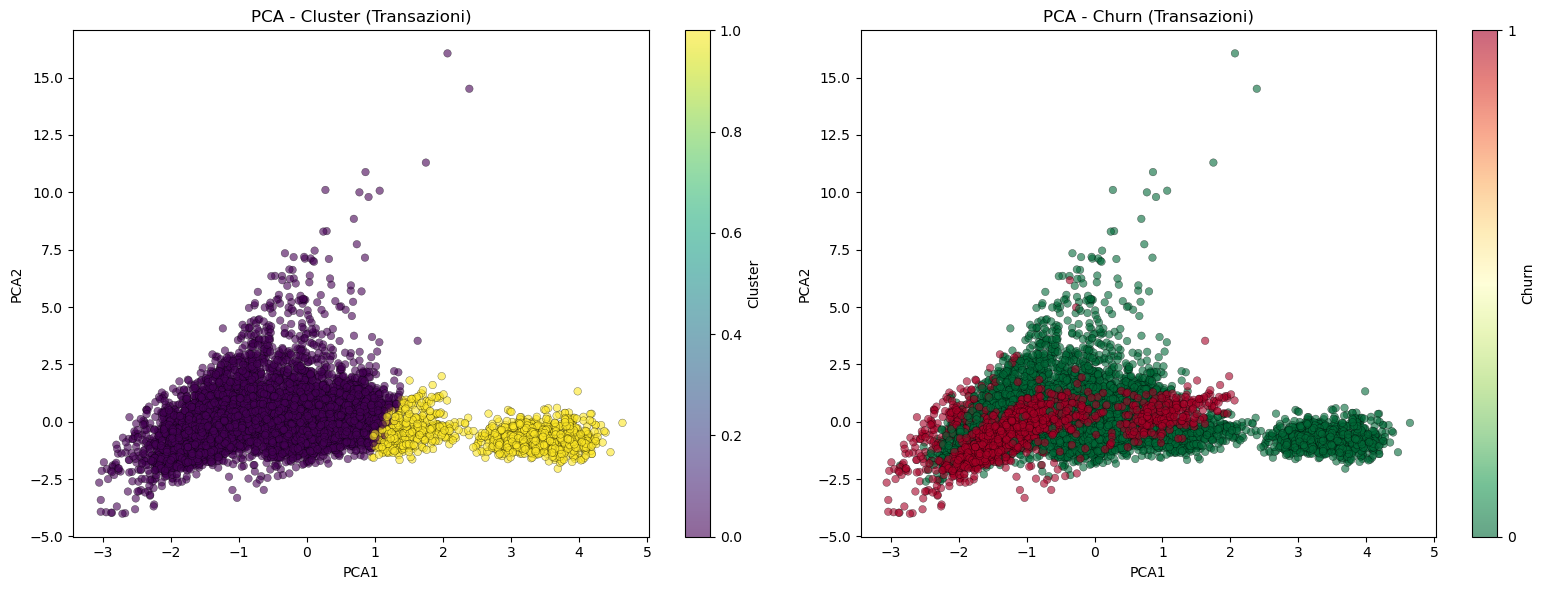


Varianza spiegata: 79.91%

--- DBSCAN Clustering ---
  eps=0.5: 3 cluster, silhouette=0.449
  eps=1.0: 2 cluster, silhouette=0.614

Migliore configurazione DBSCAN (eps=1.0):
  Silhouette: 0.614

Statistiche Cluster:
          Size  Churned  Churn_Rate
Cluster                            
-1          25        3    0.120000
 0       10094     1623    0.160789
 1           8        1    0.125000


In [5]:
# =======================
# STEP 4: Clustering per blocco tematico
# =======================
results_summary = []
cluster_labels_storage = {}

for block_name, features in blocks.items():
    print(f"\n\n{'#' * 60}")
    print(f"# ANALISI BLOCCO: {block_name}")
    print(f"{'#' * 60}\n")
    
    # Preprocessing
    preprocessor, numeric_cols, categorical_cols = build_preprocessor(features, df_clean)
    X = preprocessor.fit_transform(df_clean[features])
    
    print(f"Features trasformate: {X.shape}")
    print(f"  - Numeriche: {numeric_cols}")
    print(f"  - Categoriche: {categorical_cols}")
    
    # --- KMeans ---
    print(f"\n--- KMeans Clustering ---")
    K_range, inertias, silhouettes, optimal_k = find_optimal_k(X, max_k=8)
    plot_cluster_analysis(K_range, inertias, silhouettes, optimal_k, block_name)
    
    # Fit con k ottimale
    kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
    labels_kmeans = kmeans.fit_predict(X)
    
    # Valutazione
    results_km, cluster_stats_km = evaluate_clusters(
        X, labels_kmeans, df_clean["Attrition_Flag"], block_name + " (KMeans)"
    )
    results_summary.append(results_km)
    
    print(f"\nMetriche KMeans (k={optimal_k}):")
    print(f"  Silhouette: {results_km['Silhouette']:.3f}")
    print(f"  Davies-Bouldin: {results_km['Davies_Bouldin']:.3f}")
    print(f"  Calinski-Harabasz: {results_km['Calinski_Harabasz']:.1f}")
    
    print(f"\nStatistiche Cluster:")
    print(cluster_stats_km)
    
    # Caratterizzazione
    characterize_clusters(df_clean, features, labels_kmeans, block_name, 
                         numeric_cols, categorical_cols)
    
    # Visualizzazione
    visualize_clusters_2d(X, labels_kmeans, df_clean["Attrition_Flag"], 
                         block_name, method='PCA')
    
    # Salva etichette
    cluster_labels_storage[f"{block_name}_KMeans"] = labels_kmeans
    
    # --- DBSCAN ---
    print(f"\n--- DBSCAN Clustering ---")
    # Grid search semplificata per eps
    best_score = -1
    best_eps = None
    best_labels = None
    
    for eps in [0.5, 1.0, 1.5, 2.0, 2.5]:
        dbscan = DBSCAN(eps=eps, min_samples=5)
        labels_db = dbscan.fit_predict(X)
        n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
        
        if n_clusters > 1:
            score = silhouette_score(X, labels_db)
            print(f"  eps={eps}: {n_clusters} cluster, silhouette={score:.3f}")
            
            if score > best_score:
                best_score = score
                best_eps = eps
                best_labels = labels_db
    
    if best_labels is not None:
        results_db, cluster_stats_db = evaluate_clusters(
            X, best_labels, df_clean["Attrition_Flag"], block_name + " (DBSCAN)"
        )
        results_summary.append(results_db)
        
        print(f"\nMigliore configurazione DBSCAN (eps={best_eps}):")
        print(f"  Silhouette: {results_db['Silhouette']:.3f}")
        print(f"\nStatistiche Cluster:")
        print(cluster_stats_db)
        
        cluster_labels_storage[f"{block_name}_DBSCAN"] = best_labels
    else:
        print("DBSCAN non ha trovato cluster significativi.")




############################################################
# CLUSTERING CON TUTTE LE FEATURE
############################################################

Feature utilizzate: 19
Shape dati trasformati: (10127, 32)

--- KMeans su tutte le feature ---


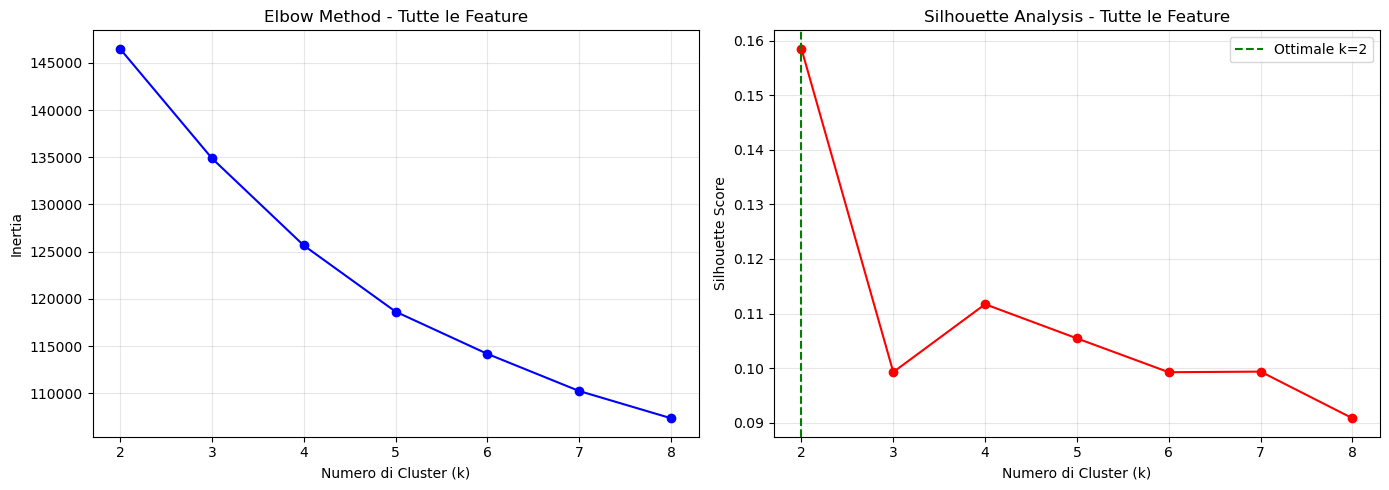


Metriche KMeans (k=2):
  Silhouette: 0.158
  Davies-Bouldin: 2.282
  Calinski-Harabasz: 1287.2

Statistiche Cluster:
         Size  Churned  Churn_Rate
Cluster                           
0        7942     1327    0.167086
1        2185      300    0.137300

CARATTERIZZAZIONE CLUSTER - Tutte le Feature


--- CLUSTER 0 (n=7942) ---

Caratteristiche numeriche medie:
  Customer_Age: 46.36 (media generale: 46.33, diff: +0.1%)
  Dependent_count: 2.30 (media generale: 2.35, diff: -2.0%)
  Months_on_book: 35.94 (media generale: 35.93, diff: +0.0%)
  Total_Relationship_Count: 3.91 (media generale: 3.81, diff: +2.5%)
  Months_Inactive_12_mon: 2.35 (media generale: 2.34, diff: +0.4%)
  Contacts_Count_12_mon: 2.45 (media generale: 2.46, diff: -0.0%)
  Credit_Limit: 4573.93 (media generale: 8631.95, diff: -47.0%)
  Total_Revolving_Bal: 1169.54 (media generale: 1162.81, diff: +0.6%)
  Avg_Open_To_Buy: 3404.40 (media generale: 7469.14, diff: -54.4%)
  Total_Amt_Chng_Q4_Q1: 0.76 (media generale: 0.76

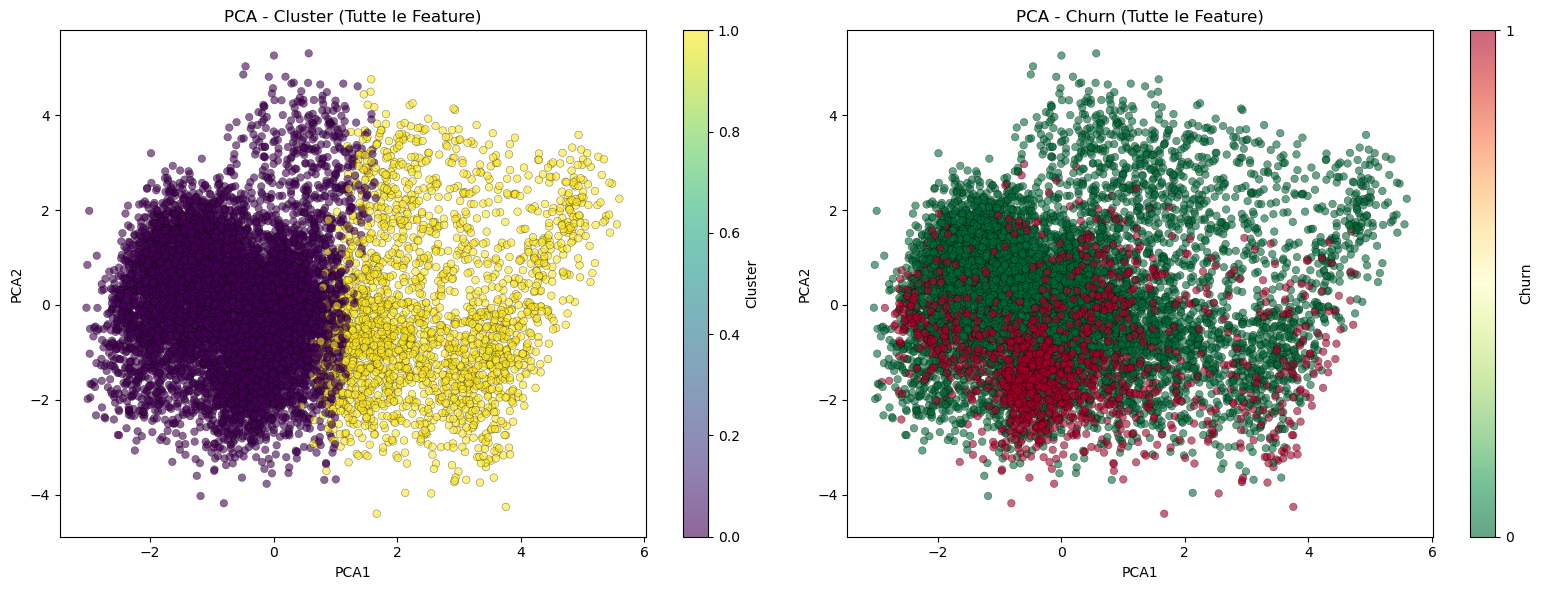


Varianza spiegata: 28.96%


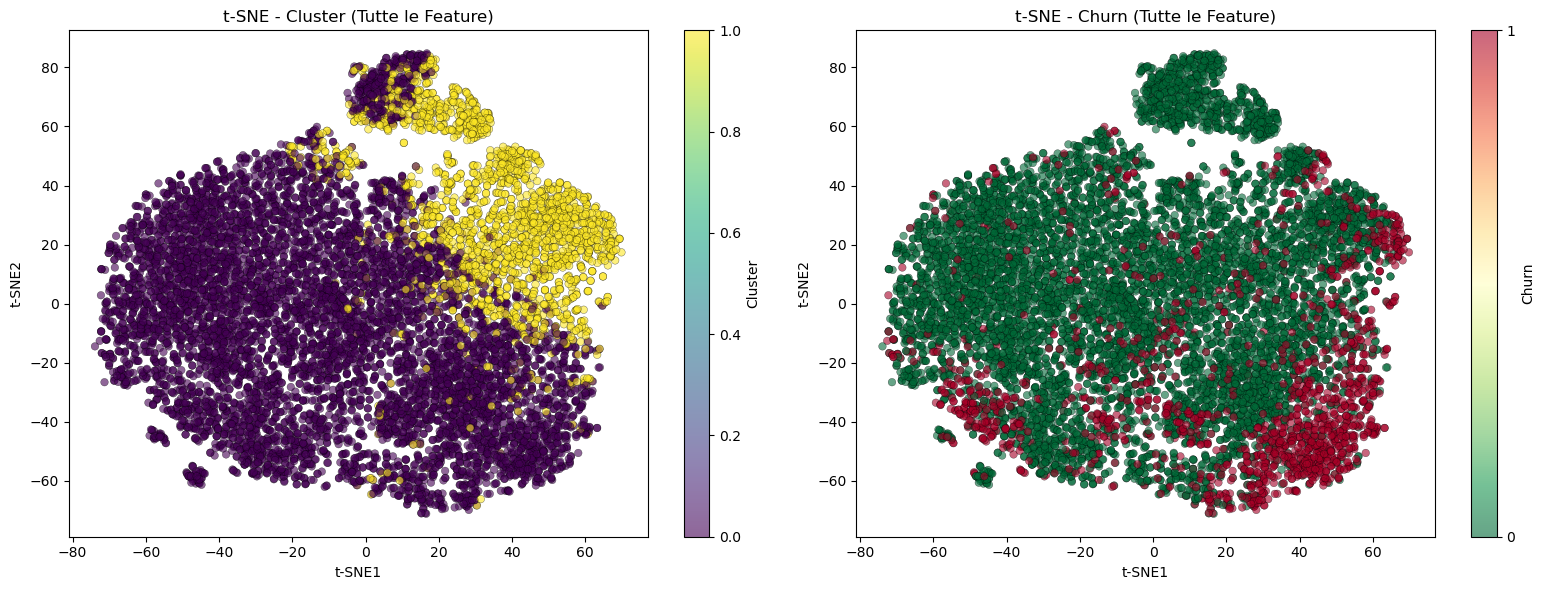

In [6]:
# =======================
# STEP 5: Clustering con TUTTE le feature
# =======================
print(f"\n\n{'#' * 60}")
print(f"# CLUSTERING CON TUTTE LE FEATURE")
print(f"{'#' * 60}\n")

# Seleziona tutte le feature (escludi ID e target)
all_features = [col for col in df_clean.columns 
                if col not in ["Attrition_Flag"]]

print(f"Feature utilizzate: {len(all_features)}")

# Preprocessing
preprocessor_all, numeric_all, categorical_all = build_preprocessor(all_features, df_clean)
X_all = preprocessor_all.fit_transform(df_clean[all_features])

print(f"Shape dati trasformati: {X_all.shape}")

# KMeans
print(f"\n--- KMeans su tutte le feature ---")
K_range, inertias, silhouettes, optimal_k = find_optimal_k(X_all, max_k=8)
plot_cluster_analysis(K_range, inertias, silhouettes, optimal_k, "Tutte le Feature")

kmeans_all = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels_all = kmeans_all.fit_predict(X_all)

results_all, cluster_stats_all = evaluate_clusters(
    X_all, labels_all, df_clean["Attrition_Flag"], "Tutte Feature (KMeans)"
)
results_summary.append(results_all)

print(f"\nMetriche KMeans (k={optimal_k}):")
print(f"  Silhouette: {results_all['Silhouette']:.3f}")
print(f"  Davies-Bouldin: {results_all['Davies_Bouldin']:.3f}")
print(f"  Calinski-Harabasz: {results_all['Calinski_Harabasz']:.1f}")

print(f"\nStatistiche Cluster:")
print(cluster_stats_all)

# Caratterizzazione (solo per alcune feature chiave)
key_features = all_features[:15]  # Prime 15 feature per evitare output troppo lungo
characterize_clusters(df_clean, key_features, labels_all, "Tutte le Feature", 
                     numeric_all[:10], categorical_all[:5])

# Visualizzazioni multiple
visualize_clusters_2d(X_all, labels_all, df_clean["Attrition_Flag"], 
                     "Tutte le Feature", method='PCA')
visualize_clusters_2d(X_all, labels_all, df_clean["Attrition_Flag"], 
                     "Tutte le Feature", method='t-SNE')

cluster_labels_storage["All_Features_KMeans"] = labels_all

In [ ]:
# =======================
# STEP 6: Riepilogo finale
# =======================
print(f"\n\n{'#' * 60}")
print(f"# RIEPILOGO COMPARATIVO")
print(f"{'#' * 60}\n")

df_results = pd.DataFrame(results_summary)
print(df_results.to_string(index=False))

print(f"\n\nMigliori configurazioni per Silhouette Score:")
print(df_results.nlargest(3, 'Silhouette')[['Block', 'N_Clusters', 'Silhouette']])

# Salva risultati
df_clean_with_clusters = df_clean.copy()
for name, labels in cluster_labels_storage.items():
    df_clean_with_clusters[f'Cluster_{name}'] = labels

print(f"\n\nDataset con cluster salvato: {df_clean_with_clusters.shape}")
print(f"Nuove colonne cluster: {[c for c in df_clean_with_clusters.columns if 'Cluster_' in c]}")

# Opzionale: salva su CSV
# df_clean_with_clusters.to_csv("BankChurners_with_clusters.csv", index=False)

print("\n" + "=" * 60)
print("ANALISI COMPLETATA")
print("=" * 60)

In [7]:



# =======================
# STEP 2: Definizione blocchi di feature
# =======================
blocks = {
    "Demografia": [
        "Customer_Age", "Gender", "Dependent_count",
        "Education_Level", "Marital_Status", "Income_Category"
    ],
    "Comportamento": [
        "Months_on_book", "Months_Inactive_12_mon",
        "Contacts_Count_12_mon", "Total_Relationship_Count"
    ],
    "Utilizzo": [
        "Credit_Limit", "Total_Revolving_Bal",
        "Avg_Open_To_Buy", "Avg_Utilization_Ratio"
    ],
    "Transazioni": [
        "Total_Trans_Amt", "Total_Trans_Ct",
        "Total_Amt_Chng_Q4_Q1", "Total_Ct_Chng_Q4_Q1"
    ]
}

# =======================
# STEP 3: Funzioni di utilità
# =======================
def build_preprocessor(features, df):
    """Crea un ColumnTransformer per numeriche (scaling) e categoriche (one-hot)."""
    numeric = df[features].select_dtypes(include=["int64", "float64"]).columns.tolist()
    categorical = df[features].select_dtypes(exclude=["int64", "float64"]).columns.tolist()
    
    transformers = []
    if numeric:
        transformers.append(("num", StandardScaler(), numeric))
    if categorical:
        transformers.append(("cat", OneHotEncoder(drop="first", sparse_output=False), categorical))
    
    preprocessor = ColumnTransformer(transformers)
    return preprocessor, numeric, categorical


def find_optimal_k(X, max_k=10):
    """Trova il k ottimale usando Elbow Method e Silhouette Score."""
    inertias = []
    silhouettes = []
    K_range = range(2, max_k + 1)
    
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        inertias.append(kmeans.inertia_)
        silhouettes.append(silhouette_score(X, labels))
    
    # Trova il k ottimale (max silhouette)
    optimal_k = K_range[np.argmax(silhouettes)]
    
    return K_range, inertias, silhouettes, optimal_k


def evaluate_clusters(X, labels, target, block_name):
    """Valuta la qualità dei cluster."""
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    results = {
        "Block": block_name,
        "N_Clusters": n_clusters,
        "Silhouette": silhouette_score(X, labels) if n_clusters > 1 else -1,
        "Davies_Bouldin": davies_bouldin_score(X, labels) if n_clusters > 1 else -1,
        "Calinski_Harabasz": calinski_harabasz_score(X, labels) if n_clusters > 1 else -1
    }
    
    # Analisi churn per cluster
    df_temp = pd.DataFrame({"Cluster": labels, "Attrition": target})
    cluster_stats = df_temp.groupby("Cluster").agg({
        "Attrition": ["count", lambda x: (x == "Attrited Customer").sum(), 
                      lambda x: (x == "Attrited Customer").mean()]
    })
    cluster_stats.columns = ["Size", "Churned", "Churn_Rate"]
    
    return results, cluster_stats


def plot_cluster_analysis(K_range, inertias, silhouettes, optimal_k, block_name):
    """Plotta Elbow e Silhouette per trovare k ottimale."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Elbow plot
    axes[0].plot(K_range, inertias, 'bo-')
    axes[0].set_xlabel('Numero di Cluster (k)')
    axes[0].set_ylabel('Inertia')
    axes[0].set_title(f'Elbow Method - {block_name}')
    axes[0].grid(True, alpha=0.3)
    
    # Silhouette plot
    axes[1].plot(K_range, silhouettes, 'ro-')
    axes[1].axvline(optimal_k, color='g', linestyle='--', label=f'Ottimale k={optimal_k}')
    axes[1].set_xlabel('Numero di Cluster (k)')
    axes[1].set_ylabel('Silhouette Score')
    axes[1].set_title(f'Silhouette Analysis - {block_name}')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def characterize_clusters(df, features, labels, block_name, numeric_cols, categorical_cols):
    """Caratterizza i cluster trovando le caratteristiche distintive."""
    df_analysis = df[features].copy()
    df_analysis['Cluster'] = labels
    
    print(f"\n{'=' * 60}")
    print(f"CARATTERIZZAZIONE CLUSTER - {block_name}")
    print(f"{'=' * 60}\n")
    
    # Analisi per ogni cluster
    for cluster_id in sorted(df_analysis['Cluster'].unique()):
        if cluster_id == -1:  # Noise in DBSCAN
            continue
            
        cluster_data = df_analysis[df_analysis['Cluster'] == cluster_id]
        print(f"\n--- CLUSTER {cluster_id} (n={len(cluster_data)}) ---")
        
        # Statistiche numeriche
        if numeric_cols:
            print("\nCaratteristiche numeriche medie:")
            for col in numeric_cols:
                cluster_mean = cluster_data[col].mean()
                overall_mean = df_analysis[col].mean()
                diff_pct = ((cluster_mean - overall_mean) / overall_mean) * 100
                print(f"  {col}: {cluster_mean:.2f} (media generale: {overall_mean:.2f}, diff: {diff_pct:+.1f}%)")
        
        # Statistiche categoriche
        if categorical_cols:
            print("\nDistribuzione variabili categoriche:")
            for col in categorical_cols:
                mode_val = cluster_data[col].mode()[0]
                mode_pct = (cluster_data[col] == mode_val).sum() / len(cluster_data) * 100
                print(f"  {col}: {mode_val} ({mode_pct:.1f}%)")


def visualize_clusters_2d(X, labels, target, block_name, method='PCA'):
    """Visualizza i cluster in 2D usando PCA o t-SNE."""
    if method == 'PCA':
        reducer = PCA(n_components=2, random_state=42)
    else:
        reducer = TSNE(n_components=2, random_state=42, perplexity=30)
    
    X_2d = reducer.fit_transform(X)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Cluster
    scatter1 = axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='viridis', 
                               alpha=0.6, s=30, edgecolors='k', linewidth=0.3)
    axes[0].set_title(f'{method} - Cluster ({block_name})')
    axes[0].set_xlabel(f'{method}1')
    axes[0].set_ylabel(f'{method}2')
    plt.colorbar(scatter1, ax=axes[0], label='Cluster')
    
    # Plot 2: Churn
    churn_binary = (target == "Attrited Customer").astype(int)
    scatter2 = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=churn_binary, cmap='RdYlGn_r', 
                               alpha=0.6, s=30, edgecolors='k', linewidth=0.3)
    axes[1].set_title(f'{method} - Churn ({block_name})')
    axes[1].set_xlabel(f'{method}1')
    axes[1].set_ylabel(f'{method}2')
    plt.colorbar(scatter2, ax=axes[1], label='Churn', ticks=[0, 1])
    
    plt.tight_layout()
    plt.show()
    
    if method == 'PCA':
        print(f"\nVarianza spiegata: {reducer.explained_variance_ratio_.sum():.2%}")


# =======================
# STEP 5: Clustering con TUTTE le feature
# =======================
print(f"\n\n{'#' * 60}")
print(f"# CLUSTERING CON TUTTE LE FEATURE")
print(f"{'#' * 60}\n")

# Seleziona tutte le feature (escludi ID e target)
all_features = [col for col in df_clean.columns 
                if col not in ["Attrition_Flag"]]

print(f"Feature utilizzate: {len(all_features)}")

# Preprocessing
preprocessor_all, numeric_all, categorical_all = build_preprocessor(all_features, df_clean)
X_all = preprocessor_all.fit_transform(df_clean[all_features])

print(f"Shape dati trasformati: {X_all.shape}")

# KMeans
print(f"\n--- KMeans su tutte le feature ---")
K_range, inertias, silhouettes, optimal_k = find_optimal_k(X_all, max_k=8)
plot_cluster_analysis(K_range, inertias, silhouettes, optimal_k, "Tutte le Feature")

kmeans_all = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels_all = kmeans_all.fit_predict(X_all)

results_all, cluster_stats_all = evaluate_clusters(
    X_all, labels_all, df_clean["Attrition_Flag"], "Tutte Feature (KMeans)"
)
results_summary.append(results_all)

print(f"\nMetriche KMeans (k={optimal_k}):")
print(f"  Silhouette: {results_all['Silhouette']:.3f}")
print(f"  Davies-Bouldin: {results_all['Davies_Bouldin']:.3f}")
print(f"  Calinski-Harabasz: {results_all['Calinski_Harabasz']:.1f}")

print(f"\nStatistiche Cluster:")
print(cluster_stats_all)

# Caratterizzazione (solo per alcune feature chiave)
key_features = all_features[:15]  # Prime 15 feature per evitare output troppo lungo
characterize_clusters(df_clean, key_features, labels_all, "Tutte le Feature", 
                     numeric_all[:10], categorical_all[:5])

# Visualizzazioni multiple
visualize_clusters_2d(X_all, labels_all, df_clean["Attrition_Flag"], 
                     "Tutte le Feature", method='PCA')
visualize_clusters_2d(X_all, labels_all, df_clean["Attrition_Flag"], 
                     "Tutte le Feature", method='t-SNE')

cluster_labels_storage["All_Features_KMeans"] = labels_all


# =======================
# STEP 6: Riepilogo finale
# =======================
print(f"\n\n{'#' * 60}")
print(f"# RIEPILOGO COMPARATIVO")
print(f"{'#' * 60}\n")

df_results = pd.DataFrame(results_summary)
print(df_results.to_string(index=False))

print(f"\n\nMigliori configurazioni per Silhouette Score:")
print(df_results.nlargest(3, 'Silhouette')[['Block', 'N_Clusters', 'Silhouette']])

# Salva risultati
df_clean_with_clusters = df_clean.copy()
for name, labels in cluster_labels_storage.items():
    df_clean_with_clusters[f'Cluster_{name}'] = labels

print(f"\n\nDataset con cluster salvato: {df_clean_with_clusters.shape}")
print(f"Nuove colonne cluster: {[c for c in df_clean_with_clusters.columns if 'Cluster_' in c]}")

# Opzionale: salva su CSV
# df_clean_with_clusters.to_csv("BankChurners_with_clusters.csv", index=False)

print("\n" + "=" * 60)
print("ANALISI COMPLETATA")
print("=" * 60)



############################################################
# RIEPILOGO COMPARATIVO
############################################################

                 Block  N_Clusters  Silhouette  Davies_Bouldin  Calinski_Harabasz
   Demografia (KMeans)           3    0.169992        1.796843        2194.024142
   Demografia (DBSCAN)         444    0.056458        1.432090          30.422220
Comportamento (KMeans)           7    0.192782        1.323882        1986.405312
Comportamento (DBSCAN)         136    0.124091        2.100404         126.746775
     Utilizzo (KMeans)           2    0.468676        0.870531        7474.626698
  Transazioni (KMeans)           2    0.407972        0.877742        3705.029334
  Transazioni (DBSCAN)           2    0.613500        0.893185         270.351006
Tutte Feature (KMeans)           2    0.158492        2.281707        1287.221796


Migliori configurazioni per Silhouette Score:
                  Block  N_Clusters  Silhouette
6  Transazioni (D